# figs 7 and 8

In [1]:
import datetime
import os
import glob
import gc
import pandas as pd
import xarray as xr
import numpy as np
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from params import basedir, wrfdir

plt.style.use('science.mplstyle')

datadir = '/glade/work/mcowherd/'
DSFDT_DIR = '/glade/work/mcowherd/dsfdt'
FIGDIR = '../figures'
TABDIR = '../tables'
os.makedirs(TABDIR, exist_ok=True)
gc.collect()

20

## Geographic data

In [2]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres')).to_crs('epsg:4269')
states_shp = gpd.read_file(f'{datadir}data/cb_2018_us_state_5m.shp').to_crs('epsg:4269')
provinces = gpd.read_file(f'{datadir}data/lpr_000b16a_e.shp').to_crs('epsg:4269')
polbd = gpd.read_file(f'{datadir}data/ne_10m_admin_1_states_provinces.shp')

ecoreg = gpd.read_file('../../us_eco_l3.shp')
ecoregrp = ecoreg.to_crs('epsg:4326')

huc8_16 = gpd.read_file(f'{datadir}data/huc16/WBDHU8.shp')
huc8_18 = gpd.read_file(f'{datadir}data/huc18/WBDHU8.shp')
huc2_10 = gpd.read_file(f'{datadir}data/huc10/WBDHU2.shp')

In [3]:
# Sierra Nevada windward / leeward divide
eco3 = gpd.read_file(f'{datadir}data/reg9_eco_l3.shp').to_crs('epsg:4326')
sn = eco3[eco3.US_L3NAME == 'Sierra Nevada']
huc8 = gpd.GeoDataFrame(pd.concat([huc8_16, huc8_18], ignore_index=True),
                        crs=huc8_18.crs).to_crs('epsg:4326')
in_sn = huc8.sjoin(sn).reset_index()
in_sn.drop_duplicates(subset='name', inplace=True)

idx_lee = [1, 4, 2, 0, 3, 29, 30, 31, 32]
idx_wind = [i for i in in_sn.index if i not in idx_lee]
combined_wind = gpd.GeoSeries(in_sn.loc[idx_wind]['geometry'].boundary).unary_union
combined_lee = gpd.GeoSeries(in_sn.loc[idx_lee]['geometry'].boundary).unary_union
gdf_overlap = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries(combined_wind.intersection(combined_lee)),
    crs=in_sn.crs)

colors_sides = {'lee': 'purple', 'wind': 'firebrick'}

In [4]:
domains = ['d01', 'd02']
coords_dict = {d: xr.open_dataset(f'{datadir}/wrfinput_{d}') for d in domains}

# index bounds into the WRF grid, per domain and region
boundaries = {'d01': {'CA': [43, 60, 35, 68],
                      'WY': [68, 81, 43, 63]},
              'd02': {'CA': [44, 125, 87, 251],
                      'WY': [165, 230, 130, 227]}}

# lat/lon bounds for the map panels
lims = {'CA': [35.7, 39.7, -121, -118],
        'WY': [42, 48, -115, -106.5]}

REGION_NAME = {'CA': 'Sierra Nevada', 'WY': 'Middle Rockies'}

## Load dSF/dT

In [5]:
def load_dsfdt(domain, which='eoc', gcm_mean=True, gcm=None, apply_mask=True):
    """Return (field, dataset) for one domain.

    which : 'eoc' or 'midc'
    gcm   : model name, when gcm_mean is False. The gcm axis is labelled
            by name, so positional selection is not used.
    """
    ds = xr.open_dataset(f'{DSFDT_DIR}/dsfdt_{domain}.nc').rename(
             {'lat2d': 'lat', 'lon2d': 'lon'})
    field = ds['dsfdt' if which == 'eoc' else 'dsfdt_midc']
    if apply_mask:
        field = field.where(ds.snowmask)
    if gcm_mean:
        field = field.mean(dim='gcm')
    elif gcm is not None:
        field = field.sel(gcm=gcm)
    return field, ds


# quick look at what is in the files
for d in domains:
    _, ds = load_dsfdt(d)
    print(d, dict(ds.sizes), '|', ds.attrs.get('quantity'))
    print('   windows:', ds.attrs.get('reference_window'), '->',
          ds.attrs.get('eoc_window'), '/', ds.attrs.get('midc_window'))
    print('   dT:', ', '.join(f'{g} {float(ds.dT.sel(gcm=g)):.1f}K'
                              for g in ds.gcm.values))

d01 {'gcm': 8, 'lat': 104, 'lon': 109} | November-April total prec_snow (WRF phase partitioning)
   windows: 1981-2010 -> 2070-2099 / 2030-2059
   dT: cesm2 3.3K, mpi-esm1-2-lr 2.5K, cnrm-esm2-1 3.2K, ec-earth3-veg 3.4K, fgoals-g3 2.4K, canesm5 4.7K, access-cm2 4.1K, ec-earth3 3.6K
d02 {'gcm': 8, 'lat': 340, 'lon': 270} | November-April total prec_snow (WRF phase partitioning)
   windows: 1981-2010 -> 2070-2099 / 2030-2059
   dT: cesm2 3.3K, mpi-esm1-2-lr 2.5K, cnrm-esm2-1 3.2K, ec-earth3-veg 3.4K, fgoals-g3 2.4K, canesm5 4.7K, access-cm2 4.1K, ec-earth3 3.6K


## color. from stefan's feedback

In [6]:
# OVERRIDE = {}   # e.g. {'CA': (-150, 80), 'WY': (-60, 30)}


def nice(x, step=10):
    return float(np.sign(x) * np.ceil(abs(x) / step) * step)


# def scale_for(state, q=(2, 98)):
#     if state in OVERRIDE:
#         return OVERRIDE[state]
#     vals = []
#     for d in domains:
#         field, _ = load_dsfdt(d)
#         latmin, latmax, lonmin, lonmax = lims[state]
#         c = coords_dict[d].rename({'south_north': 'lat', 'west_east': 'lon'})
#         inbox = ((c.XLAT[0] >= latmin) & (c.XLAT[0] <= latmax) &
#                  (c.XLONG[0] >= lonmin) & (c.XLONG[0] <= lonmax))
#         v = field.where(inbox).values.ravel()
#         vals.append(v[np.isfinite(v)])
#     v = np.concatenate(vals)
#     lo, hi = np.percentile(v, q)
#     return nice(lo), max(nice(hi), 10.0)


# # SCALE = {s: scale_for(s) for s in ['CA', 'WY']}
# # print('colour / axis limits [mm K-1]:', SCALE)



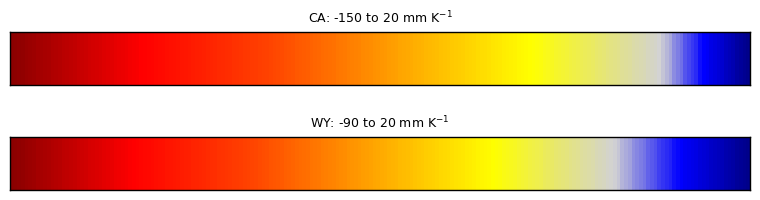

In [7]:
def zero_center_cmap(vmin, vmax):
    """Diverging map with the neutral colour pinned at zero."""
    cols = ['darkred', 'red', 'orangered', 'orange', 'yellow',
            'lightgray', 'blue', 'darkblue']
    white = 5
    z = (0 - vmin) / (vmax - vmin)
    pos = [(i / white) * z if i <= white
           else z + ((i - white) / (len(cols) - 1 - white)) * (1 - z)
           for i in range(len(cols))]
    return LinearSegmentedColormap.from_list('dsfdt', list(zip(pos, cols)))

SCALE = {'CA': (-150.0, 20.0), 'WY': (-90.0, 20.0)}

CMAP = {s: zero_center_cmap(*SCALE[s]) for s in SCALE}

fig, axl = plt.subplots(2, 1, figsize=(8, 2.4))
for a, s in zip(axl, SCALE):
    vmin, vmax = SCALE[s]
    a.imshow(np.linspace(vmin, vmax, 200).reshape(1, -1), cmap=CMAP[s],
             vmin=vmin, vmax=vmax, aspect='auto')
    a.set_yticks([]); a.set_xticks([])
    a.set_title(f'{s}: {vmin:g} to {vmax:g} mm K$^{{-1}}$', fontsize=9)
plt.tight_layout(); plt.show()

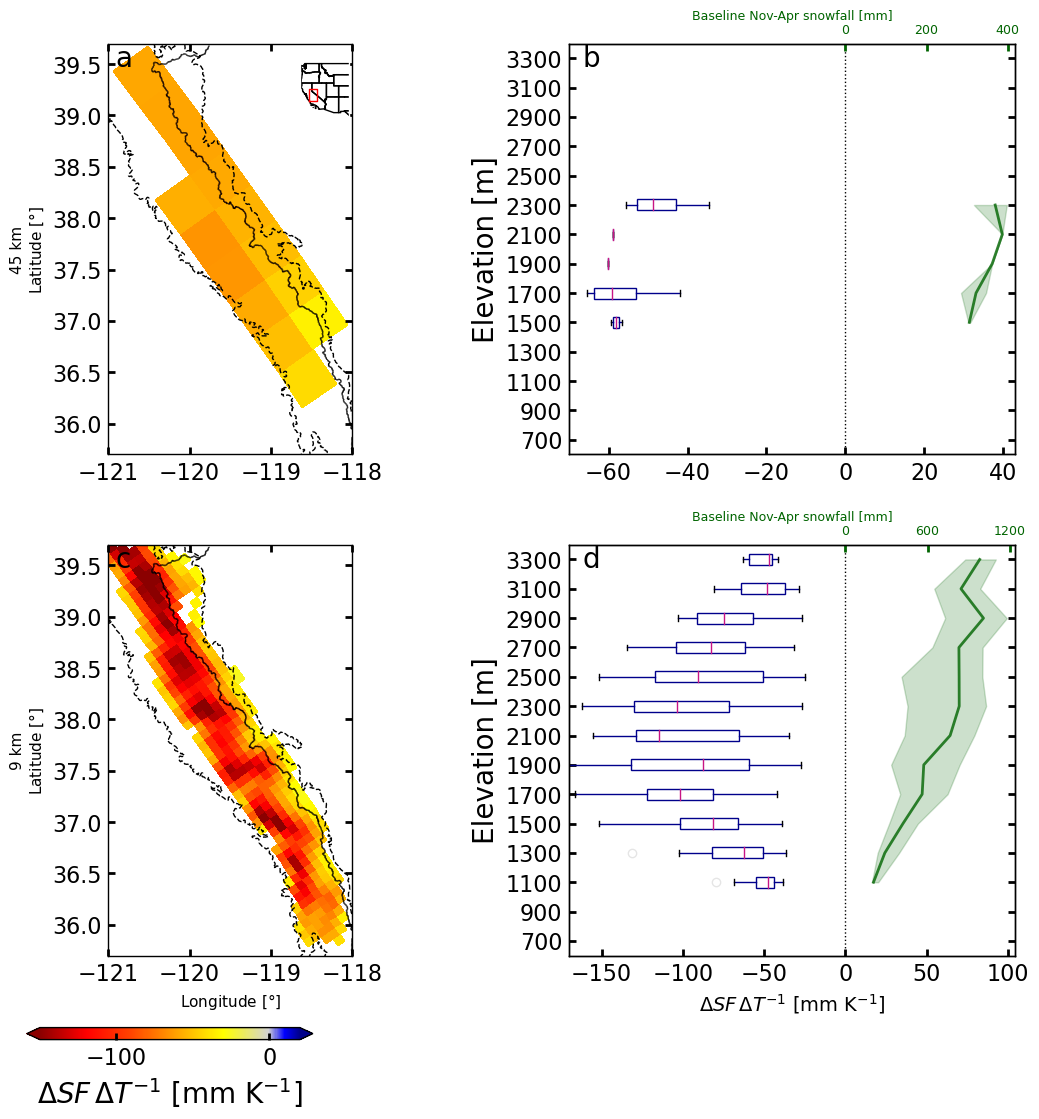

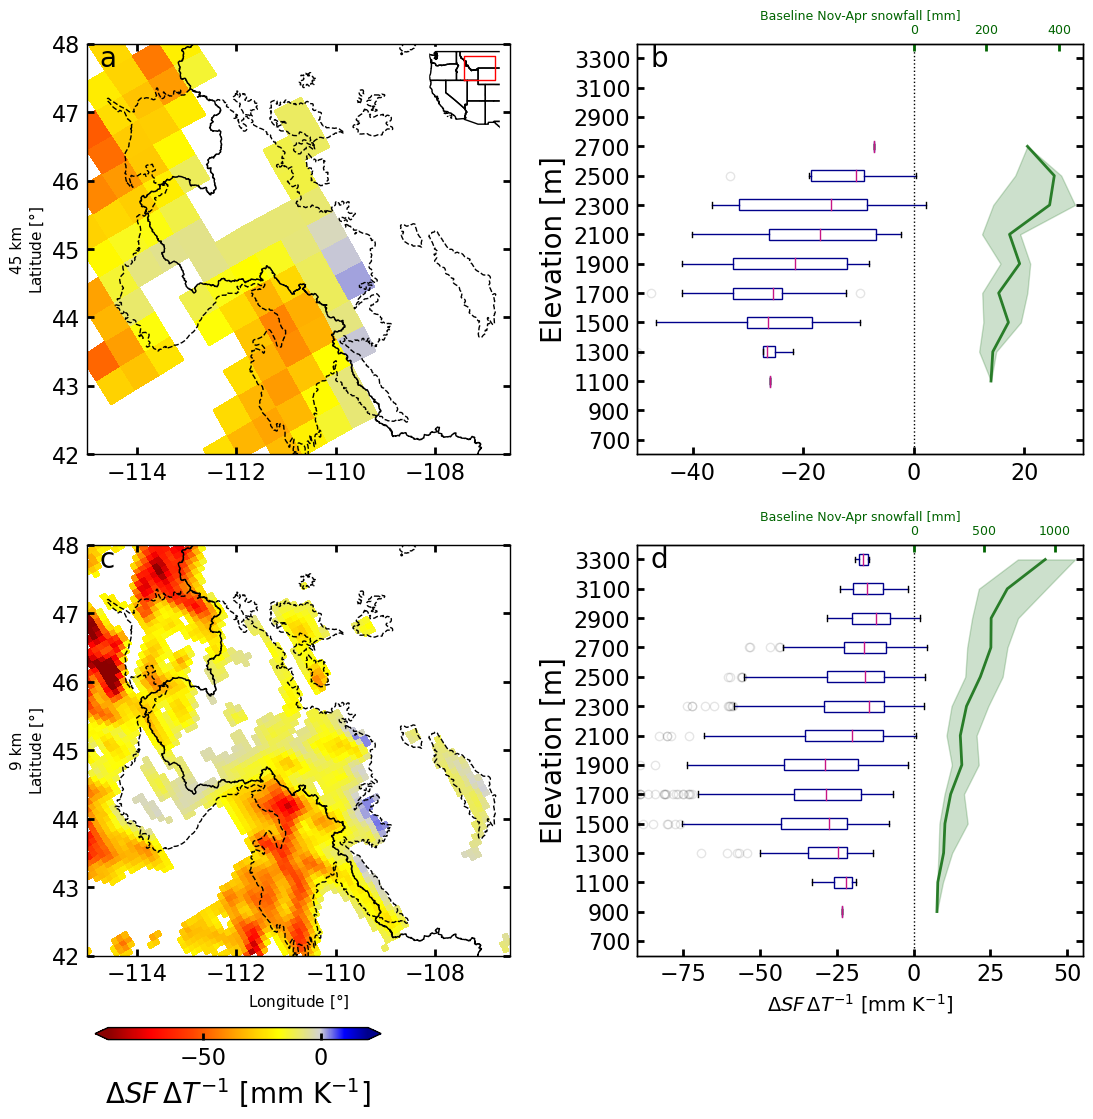

Sierra Nevada, 9 km
  fractional: -22.9 %/K at 1100 m -> -5.9 %/K at 3100 m
  strongest absolute: -114 mm/K at 2100-2300 m
  positive cells: 0% max in any band
Middle Rockies, 9 km
  fractional: -11.8 %/K at 1300 m -> -2.1 %/K at 3100 m
  strongest absolute: -29 mm/K at 1900-2100 m
  positive cells: 6% max in any band


In [19]:
# =====================================================================
# actual fig pltting here
# =====================================================================
BAND_SIZE = 200
BANDS = np.arange(500, 3500, BAND_SIZE)
RES_LABEL = {'d01': '45 km', 'd02': '9 km'}
ZERO_AT = 0.62 # zero sits this far across; boxes left, green right. manual edit! 

all_rows = []

for state in ['CA', 'WY']:
    fig, ax = plt.subplots(2, 2, figsize=(13, 12))
    axs = ax.flatten()
    latmin, latmax, lonmin, lonmax = lims[state]
    vmin, vmax = SCALE[state]

    for i, domain in enumerate(domains):
        per_gcm, ds = load_dsfdt(domain, 'eoc', gcm_mean=False)
        per_gcm = per_gcm.where(ds.snowmask)
        ens = per_gcm.mean(dim='gcm')
        base = ds.baseline_sf.where(ds.snowmask)

        coords = coords_dict[domain].rename(
                     {'south_north': 'lat', 'west_east': 'lon'})
        lat, lon, elev = coords.XLAT[0], coords.XLONG[0], coords.HGT[0]
        inbox = ((lat >= latmin) & (lat <= latmax) &
                 (lon >= lonmin) & (lon <= lonmax))
        ens, per_gcm = ens.where(inbox), per_gcm.where(inbox)
        base, myelev = base.where(inbox), elev.where(inbox)

        # map
        cb = ax[i, 0].pcolormesh(lon, lat, ens, cmap=CMAP[state],
                                 vmin=vmin, vmax=vmax)
        ax[i, 0].set_xlim(lonmin, lonmax)
        ax[i, 0].set_ylim(latmin, latmax)
        ax[i, 0].set_ylabel(f'{RES_LABEL[domain]}\n' r'Latitude [$\degree$]',
                            fontsize=11)
        ecoregrp[ecoregrp.US_L3NAME == REGION_NAME[state]].boundary.plot(
            ax=ax[i, 0], linestyle='--')
        if state == 'CA':
            gdf_overlap.plot(ax=ax[i, 0], color='k', linestyle='-')
        else:
            huc2_10.boundary.plot(ax=ax[i, 0], color='k', linestyle='-')
       
        # per-gridcell fractional sensitivity
        pct_field = 100 * ens / base.where(base > 0)

        groups, snow_groups = [], []
        for band in BANDS:
            m = (myelev >= band) & (myelev < band + BAND_SIZE)
            v = ens.where(m).values.ravel();       v = v[np.isfinite(v)]
            s = base.where(m).values.ravel();      s = s[np.isfinite(s)]
            p = pct_field.where(m).values.ravel(); p = p[np.isfinite(p)]
            groups.append(v); snow_groups.append(s)
            if v.size == 0:
                continue
            per = [float(per_gcm.sel(gcm=g).where(m).median())
                   for g in per_gcm.gcm.values]
            all_rows.append({
                'state': state, 'region': REGION_NAME[state],
                'domain': domain, 'elev_band_m': int(band),
                'n_cells': int(v.size),
                'median_mm_per_K': np.median(v),
                'q1_mm_per_K': np.percentile(v, 25),
                'q3_mm_per_K': np.percentile(v, 75),
                'gcm_sd_mm_per_K': float(np.nanstd(per)),
                'baseline_sf_mm': np.median(s) if s.size else np.nan,
                'median_pct_per_K': np.median(p) if p.size else np.nan,
                'q1_pct_per_K': np.percentile(p, 25) if p.size else np.nan,
                'q3_pct_per_K': np.percentile(p, 75) if p.size else np.nan,
                'frac_cells_positive': float((v > 0).mean())})

        # add the boxplots
        ax[i, 1].boxplot(groups, vert=False, bootstrap=1000,
                         positions=BANDS, widths=75,
                         flierprops={'alpha': 0.1, 'color': 'darkblue'},
                         patch_artist=True,
                         boxprops={'color': 'darkblue', 'facecolor': 'white'},
                         whiskerprops={'color': 'darkblue'},
                         medianprops={'color': 'mediumvioletred'})

        allv = np.concatenate([g for g in groups if g.size])
        blo = nice(np.percentile(allv, 1))
        bhi = abs(blo) * (1 - ZERO_AT) / ZERO_AT
        ax[i, 1].set_xlim(blo, bhi)
        ax[i, 1].plot([0, 0], [500, 3600], 'k:')
        ax[i, 1].set_ylim(600, 3400)
        ax[i, 1].set_ylabel('Elevation [m]')

        # baseline period snowfall
        med_s = [np.median(s) if s.size else np.nan for s in snow_groups]
        q1s = [np.percentile(s, 25) if s.size else np.nan for s in snow_groups]
        q3s = [np.percentile(s, 75) if s.size else np.nan for s in snow_groups]

        ax_snow = ax[i, 1].twiny()
        ax_snow.fill_betweenx(BANDS, q1s, q3s, alpha=0.2, color='darkgreen')
        ax_snow.plot(med_s, BANDS, color='darkgreen', lw=2, alpha=0.8)
        ax_snow.xaxis.tick_top()
        smax = 1.05 * np.nanmax(q3s)
        ax_snow.set_xlim(-smax * ZERO_AT / (1 - ZERO_AT), smax)
        ax_snow.set_xticks(np.linspace(0, np.floor(smax / 200) * 200, 3))
        ax_snow.tick_params(axis='x', colors='darkgreen', labelsize=9)
        ax_snow.set_xlabel('Baseline Nov-Apr snowfall [mm]',
                           color='darkgreen', fontsize=9, labelpad=3)

    ax[1, 0].set_xlabel(r'Longitude [$\degree$]', fontsize=11)
    ax[1, 1].set_xlabel(r'$\Delta SF\,\Delta T^{-1}$ [mm K$^{-1}$]', size=14)

    cax = fig.add_axes([0.14, 0.05, 0.22, 0.010])
    plt.colorbar(cb, cax=cax, orientation='horizontal', extend='both',
                 label=r'$\Delta SF\,\Delta T^{-1}$ [mm K$^{-1}$]')

    inset_ax = inset_axes(ax[0, 0], width='20%', height='20%', loc=1,
                          borderpad=0.2,
                          axes_kwargs={'facecolor': 'white',
                                       'xticklabels': [], 'yticklabels': []})
    inset_ax.tick_params(bottom=False, left=False, right=False, top=False)
    states_shp.boundary.plot(ax=inset_ax)
    inset_ax.plot([lonmin, lonmax, lonmax, lonmin, lonmin],
                  [latmin, latmin, latmax, latmax, latmin], color='red')
    inset_ax.set_xlim(-125, -105); inset_ax.set_ylim(30, 50)
    for sp in inset_ax.spines.values():
        sp.set_color('w')

    for k, myax in enumerate(axs):
        myax.text(0.03, 0.945, chr(k + 97), transform=myax.transAxes)

    plt.subplots_adjust(bottom=0.12, wspace=0.26, hspace=0.22)
    plt.savefig(f'{FIGDIR}/fig_dsfdt_{state}.jpg', dpi=400, bbox_inches='tight')
    plt.show()
    gc.collect()

df = pd.DataFrame(all_rows)
df.to_csv(f'{TABDIR}/dsfdt_bands.csv', index=False)

# numerical output
for state in ['CA', 'WY']:
    g = df[(df.state == state) & (df.domain == 'd02')].sort_values('elev_band_m')
    g = g[g.n_cells >= 10]
    lo_, hi_ = g.iloc[0], g.iloc[-1]
    worst = g.loc[g.median_mm_per_K.idxmin()]
    print(f'{REGION_NAME[state]}, 9 km')
    print(f'  fractional: {lo_.median_pct_per_K:.1f} %/K at {int(lo_.elev_band_m)} m '
          f'-> {hi_.median_pct_per_K:.1f} %/K at {int(hi_.elev_band_m)} m')
    print(f'  strongest absolute: {worst.median_mm_per_K:.0f} mm/K at '
          f'{int(worst.elev_band_m)}-{int(worst.elev_band_m + BAND_SIZE)} m')
    print(f'  positive cells: {100 * g.frac_cells_positive.max():.0f}% max in any band')

In [9]:
g = df[(df.state == 'WY') & (df.domain == 'd02')]
print(g.loc[g.frac_cells_positive.idxmax(),
            ['elev_band_m', 'frac_cells_positive', 'n_cells']].to_dict())

{'elev_band_m': 2700, 'frac_cells_positive': 0.05660377358490566, 'n_cells': 106}


In [10]:
g = df[(df.state=='CA') & (df.domain=='d02') & df.elev_band_m.between(1700,2300)]
print(g[['elev_band_m','median_mm_per_K','baseline_sf_mm','n_cells']].to_string(index=False))
print(g.median_mm_per_K.mean())

 elev_band_m  median_mm_per_K  baseline_sf_mm  n_cells
        1700      -101.704453      560.918091       40
        1900       -87.720001      572.534119       51
        2100      -114.432549      765.406921       49
        2300      -103.309235      831.966003       38
-101.79156


In [11]:
g = df[(df.state=='CA') & (df.domain=='d02') &
       df.elev_band_m.isin([1100, 3100])]
print(g[['elev_band_m','median_mm_per_K','median_pct_per_K',
         'baseline_sf_mm','n_cells']].to_string(index=False))

 elev_band_m  median_mm_per_K  median_pct_per_K  baseline_sf_mm  n_cells
        1100       -47.718765        -22.902838      204.939880       15
        3100       -48.160347         -5.929903      844.960938       19


In [12]:
g = df[(df.state=='CA') & (df.domain=='d02') &
       df.elev_band_m.between(3100,10000)]
print(g[['elev_band_m','median_mm_per_K','median_pct_per_K',
         'baseline_sf_mm','n_cells']].to_string(index=False))

print(g.median_mm_per_K.mean())

 elev_band_m  median_mm_per_K  median_pct_per_K  baseline_sf_mm  n_cells
        3100       -48.160347         -5.929903      844.960938       19
        3300       -46.978386         -5.281199      981.816040        9
-47.569366


In [13]:
g = df[(df.state=='WY') & (df.domain=='d02') &
       df.elev_band_m.isin([1100, 1900, 2100, 3100])]
print(g[['elev_band_m','median_mm_per_K','median_pct_per_K',
         'baseline_sf_mm','n_cells']].to_string(index=False))

 elev_band_m  median_mm_per_K  median_pct_per_K  baseline_sf_mm  n_cells
        1100       -22.092237        -12.543033      170.543411        9
        1900       -28.751987         -7.882409      340.947754      371
        2100       -19.992664         -5.863262      330.117767      358
        3100       -15.105988         -2.112224      662.802734       32


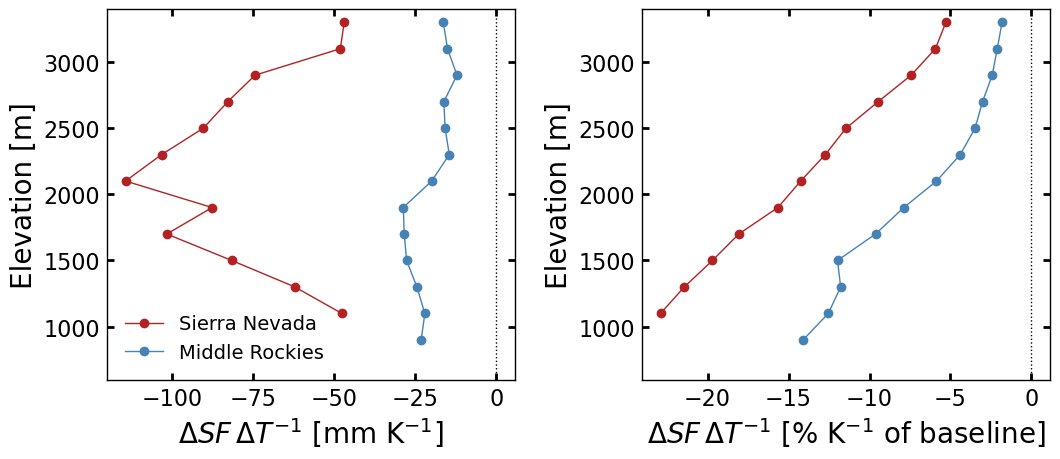

Sierra Nevada: strongest absolute 2100 m, strongest fractional 1100 m
Middle Rockies: strongest absolute 1900 m, strongest fractional 900 m


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for state, c in [('CA', 'firebrick'), ('WY', 'steelblue')]:
    g = df[(df.state == state) & (df.domain == 'd02')].sort_values('elev_band_m')
    ax[0].plot(g.median_mm_per_K, g.elev_band_m, 'o-', color=c,
               label=REGION_NAME[state])
    ax[1].plot(g.median_pct_per_K, g.elev_band_m, 'o-', color=c)

ax[0].set_xlabel(r'$\Delta SF\,\Delta T^{-1}$ [mm K$^{-1}$]')
ax[1].set_xlabel(r'$\Delta SF\,\Delta T^{-1}$ [% K$^{-1}$ of baseline]')
for a in ax:
    a.axvline(0, color='k', ls=':'); a.set_ylabel('Elevation [m]')
    a.set_ylim(600, 3400)
ax[0].legend()
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_dsfdt_abs_vs_pct.jpg', dpi=300, bbox_inches='tight')
plt.show()
gc.collect()

for state in ['CA', 'WY']:
    g = df[(df.state == state) & (df.domain == 'd02')]
    print(f'{REGION_NAME[state]}: strongest absolute '
          f'{int(g.loc[g.median_mm_per_K.idxmin()].elev_band_m)} m, '
          f'strongest fractional '
          f'{int(g.loc[g.median_pct_per_K.idxmin()].elev_band_m)} m')

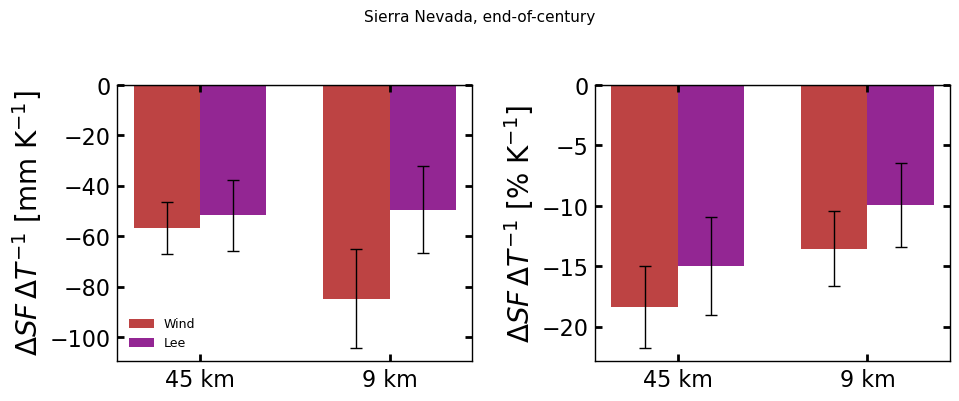

45 km: wind -56.7 mm/K (-18.4 %/K), lee -51.8 mm/K (-15.0 %/K)  |  ratio 1.09x abs, 1.23x frac
9 km: wind -84.7 mm/K (-13.5 %/K), lee -49.4 mm/K (-9.9 %/K)  |  ratio 1.71x abs, 1.37x frac


,domain,side,n_cells,median_mm_per_K,gcm_sd_mm_per_K,baseline_sf_mm,median_pct_per_K,gcm_sd_pct_per_K
0,d01,wind,13,-56.654850,10.380470,308.352570,-18.373400,3.366429
1,d01,lee,5,-51.756248,14.018769,345.586517,-14.976351,4.056515
2,d02,wind,398,-84.730865,19.594454,626.674805,-13.520707,3.126734
3,d02,lee,76,-49.422974,17.387411,498.993744,-9.904528,3.484495


In [15]:
# =====================================================================
# orography
# =====================================================================
rows = []
for domain in domains:
    per_gcm, ds = load_dsfdt(domain, 'eoc', gcm_mean=False)
    per_gcm = per_gcm.where(ds.snowmask)
    ens = per_gcm.mean(dim='gcm')
    base = ds.baseline_sf.where(ds.snowmask)

    sidemasks = xr.open_dataset(f'{datadir}masks_{domain}_sn.nc')
    for side in list(sidemasks.side.values):
        m = sidemasks.sel(side=side).basin_mask.values.astype(bool)
        v = ens.where(m).values.ravel(); v = v[np.isfinite(v)]
        b = base.where(m).values.ravel(); b = b[np.isfinite(b)]
        if v.size == 0:
            continue
        per = [float(per_gcm.sel(gcm=g).where(m).median())
               for g in per_gcm.gcm.values]
        ref = np.nanmean(b)
        rows.append({'domain': domain, 'side': str(side),
                     'n_cells': int(v.size),
                     'median_mm_per_K': float(np.median(v)),
                     'gcm_sd_mm_per_K': float(np.nanstd(per)),
                     'baseline_sf_mm': ref,
                     'median_pct_per_K': 100 * np.median(v) / ref,
                     'gcm_sd_pct_per_K': float(np.nanstd(per)) / ref * 100})

sides_df = pd.DataFrame(rows)
sides_df.to_csv(f'{TABDIR}/dsfdt_sides_CA.csv', index=False)

#barplots
order = sorted(sides_df.side.unique(),
               key=lambda s: 0 if 'wind' in s.lower() else 1)
cols = {s: ('firebrick' if 'wind' in s.lower() else 'purple') for s in order}
labels = {'d01': '45 km', 'd02': '9 km'}
x = np.arange(len(domains))
w = 0.35

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for j, (col, err, lab) in enumerate([
        ('median_mm_per_K', 'gcm_sd_mm_per_K',
         r'$\Delta SF\,\Delta T^{-1}$ [mm K$^{-1}$]'),
        ('median_pct_per_K', 'gcm_sd_pct_per_K',
         r'$\Delta SF\,\Delta T^{-1}$ [% K$^{-1}$]')]):
    for k, side in enumerate(order):
        g = sides_df[sides_df.side == side].set_index('domain').reindex(domains)
        ax[j].bar(x + (k - 0.5) * w, g[col], w, yerr=g[err], capsize=4,
                  color=cols[side], alpha=0.85,
                  label=side.capitalize() if j == 0 else None)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels([labels.get(d, d) for d in domains])
    ax[j].axhline(0, color='k', lw=0.8)
    ax[j].set_ylabel(lab)
ax[0].legend(fontsize=9)
fig.suptitle('Sierra Nevada, end-of-century', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_dsfdt_sides_bar.jpg', dpi=300, bbox_inches='tight')
plt.show()

for domain in domains:
    g = sides_df[sides_df.domain == domain].set_index('side')
    if len(g) == 2:
        a, b = order
        print(f'{labels.get(domain, domain)}: '
              f'{a} {g.median_mm_per_K[a]:.1f} mm/K ({g.median_pct_per_K[a]:.1f} %/K), '
              f'{b} {g.median_mm_per_K[b]:.1f} mm/K ({g.median_pct_per_K[b]:.1f} %/K)  |  '
              f'ratio {g.median_mm_per_K[a] / g.median_mm_per_K[b]:.2f}x abs, '
              f'{g.median_pct_per_K[a] / g.median_pct_per_K[b]:.2f}x frac')

sides_df

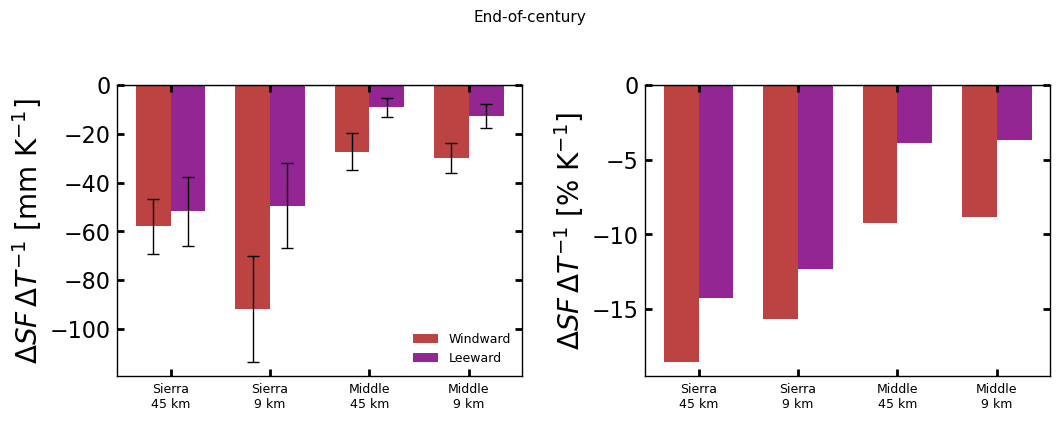

--- eoc ---
  Sierra Nevada   45 km  wind   -57.9 mm/K (-18.6 %/K, n=9)   lee   -51.8 mm/K (-14.3 %/K, n=5)   ratio 1.12x abs, 1.30x frac
  Sierra Nevada   9 km   wind   -91.9 mm/K (-15.6 %/K, n=290)   lee   -49.4 mm/K (-12.3 %/K, n=76)   ratio 1.86x abs, 1.27x frac
  Middle Rockies  45 km  wind   -27.3 mm/K ( -9.3 %/K, n=61)   lee    -9.2 mm/K ( -3.9 %/K, n=26)   ratio 2.97x abs, 2.40x frac
  Middle Rockies  9 km   wind   -30.0 mm/K ( -8.8 %/K, n=1328)   lee   -12.7 mm/K ( -3.7 %/K, n=756)   ratio 2.36x abs, 2.39x frac

--- midc ---
  Sierra Nevada   45 km  wind   -57.9 mm/K (-18.3 %/K, n=9)   lee   -39.1 mm/K (-10.7 %/K, n=5)   ratio 1.48x abs, 1.71x frac
  Sierra Nevada   9 km   wind   -74.0 mm/K (-13.3 %/K, n=290)   lee   -33.7 mm/K ( -8.7 %/K, n=76)   ratio 2.20x abs, 1.52x frac
  Middle Rockies  45 km  wind   -26.4 mm/K ( -8.6 %/K, n=61)   lee    -7.7 mm/K ( -2.8 %/K, n=26)   ratio 3.44x abs, 3.01x frac
  Middle Rockies  9 km   wind   -28.0 mm/K ( -8.1 %/K, n=1328)   lee   -10.5 

,state,region,domain,period,side,n_cells,median_mm_per_K,q1_mm_per_K,q3_mm_per_K,gcm_sd_mm_per_K,baseline_sf_mm,median_pct_per_K,q1_pct_per_K,q3_pct_per_K,frac_cells_positive
0,CA,Sierra Nevada,d01,eoc,wind,9,-57.946686,-60.341354,-55.674541,11.209531,310.303650,-18.558102,-18.690966,-18.437458,0.000000
1,CA,Sierra Nevada,d01,eoc,lee,5,-51.756248,-58.766090,-45.687061,14.018769,361.692200,-14.284055,-15.200767,-13.367276,0.000000
2,CA,Sierra Nevada,d01,midc,wind,9,-57.910240,-64.200264,-49.367840,21.591195,310.303650,-18.269541,-18.539721,-17.863094,0.000000
3,CA,Sierra Nevada,d01,midc,lee,5,-39.148109,-51.675236,-33.192001,33.708745,361.692200,-10.655783,-13.366606,-9.876593,0.000000
4,CA,Sierra Nevada,d02,eoc,wind,290,-91.858871,-121.227592,-63.240866,21.725711,742.817505,-15.634358,-19.107363,-11.401882,0.000000
5,CA,Sierra Nevada,d02,eoc,lee,76,-49.422974,-65.286594,-35.779117,17.387411,443.059265,-12.319775,-14.229428,-9.605987,0.000000
6,CA,Sierra Nevada,d02,midc,wind,290,-74.034760,-99.818205,-49.257742,54.809433,742.817505,-13.305147,-19.074464,-7.451708,0.006897
7,CA,Sierra Nevada,d02,midc,lee,76,-33.696632,-51.578844,-21.352310,39.442694,443.059265,-8.740980,-12.084042,-5.102986,0.000000
8,WY,Middle Rockies,d01,eoc,wind,61,-27.254288,-33.255814,-19.363974,7.614193,280.210815,-9.271351,-11.602011,-7.760942,0.000000
9,WY,Middle Rockies,d01,eoc,lee,26,-9.190683,-12.245044,-6.765407,3.838385,235.119171,-3.866487,-5.381957,-2.616652,0.115385


In [17]:
# =====================================================================
# more orographic, expand geog! 
# =====================================================================
from shapely.ops import unary_union

MISSOURI = unary_union(huc2_10.to_crs('epsg:4326').geometry.values)
PERIODS = ['eoc', 'midc']


def region_box(state, lat, lon):
    latmin, latmax, lonmin, lonmax = lims[state]
    return ((np.asarray(lat) >= latmin) & (np.asarray(lat) <= latmax) &
            (np.asarray(lon) >= lonmin) & (np.asarray(lon) <= lonmax))


def side_masks(domain, state, lat, lon):
    """dict of side name -> boolean array on the model grid, box-clipped."""
    box = region_box(state, lat, lon)

    if state == 'CA':
        sm = xr.open_dataset(f'{datadir}masks_{domain}_sn.nc')
        out = {}
        for s in sm.side.values:
            name = 'wind' if 'wind' in str(s).lower() else 'lee'
            out[name] = sm.sel(side=s).basin_mask.values.astype(bool) & box
        return out

    la, lo_ = np.asarray(lat), np.asarray(lon)
    pts = gpd.GeoSeries(gpd.points_from_xy(lo_[box], la[box]), crs='epsg:4326')
    inside = np.zeros(box.shape, dtype=bool)
    inside[box] = pts.within(MISSOURI).values
    return {'wind': box & ~inside, 'lee': box & inside}


rows = []
for state in ['CA', 'WY']:
    for domain in domains:
        c = coords_dict[domain]
        masks = side_masks(domain, state, c.XLAT[0], c.XLONG[0])

        for which in PERIODS:
            per_gcm, ds = load_dsfdt(domain, which, gcm_mean=False)
            per_gcm = per_gcm.where(ds.snowmask)
            ens = per_gcm.mean(dim='gcm')
            base = ds.baseline_sf.where(ds.snowmask)
            pct_field = 100 * ens / base.where(base > 0)   # per cell

            for side, m in masks.items():
                v = ens.where(m).values.ravel();       v = v[np.isfinite(v)]
                b = base.where(m).values.ravel();      b = b[np.isfinite(b)]
                p = pct_field.where(m).values.ravel(); p = p[np.isfinite(p)]
                if v.size == 0:
                    continue
                per = [float(per_gcm.sel(gcm=g).where(m).median())
                       for g in per_gcm.gcm.values]
                rows.append({
                    'state': state, 'region': REGION_NAME[state],
                    'domain': domain, 'period': which, 'side': side,
                    'n_cells': int(v.size),
                    'median_mm_per_K': float(np.median(v)),
                    'q1_mm_per_K': float(np.percentile(v, 25)),
                    'q3_mm_per_K': float(np.percentile(v, 75)),
                    'gcm_sd_mm_per_K': float(np.nanstd(per)),
                    'baseline_sf_mm': float(np.median(b)),
                    'median_pct_per_K': float(np.median(p)),
                    'q1_pct_per_K': float(np.percentile(p, 25)),
                    'q3_pct_per_K': float(np.percentile(p, 75)),
                    'frac_cells_positive': float((v > 0).mean())})

sides_df = pd.DataFrame(rows)
sides_df.to_csv(f'{TABDIR}/dsfdt_sides.csv', index=False)

#barplots
order = ['wind', 'lee']
cols = {'wind': 'firebrick', 'lee': 'purple'}
labels = {'d01': '45 km', 'd02': '9 km'}
groups_x = [(s, d) for s in ['CA', 'WY'] for d in domains]
x = np.arange(len(groups_x))
w = 0.35

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for j, (col, err, lab) in enumerate([
        ('median_mm_per_K', 'gcm_sd_mm_per_K',
         r'$\Delta SF\,\Delta T^{-1}$ [mm K$^{-1}$]'),
        ('median_pct_per_K', None,
         r'$\Delta SF\,\Delta T^{-1}$ [% K$^{-1}$]')]):
    for k, side in enumerate(order):
        vals, errs = [], []
        for s, d in groups_x:
            g = sides_df[(sides_df.state == s) & (sides_df.domain == d) &
                         (sides_df.period == 'eoc') & (sides_df.side == side)]
            vals.append(g[col].iloc[0] if len(g) else np.nan)
            errs.append(g[err].iloc[0] if (err and len(g)) else np.nan)
        ax[j].bar(x + (k - 0.5) * w, vals, w,
                  yerr=errs if err else None, capsize=4,
                  color=cols[side], alpha=0.85,
                  label=('Windward' if side == 'wind' else 'Leeward')
                        if j == 0 else None)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels([f'{REGION_NAME[s].split()[0]}\n{labels.get(d, d)}'
                           for s, d in groups_x], fontsize=9)
    ax[j].axhline(0, color='k', lw=0.8)
    ax[j].set_ylabel(lab)
ax[0].legend(fontsize=9)
fig.suptitle('End-of-century', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_dsfdt_sides_bar.jpg', dpi=300, bbox_inches='tight')
plt.show()

#more numbers
for which in PERIODS:
    print(f'--- {which} ---')
    for s in ['CA', 'WY']:
        for d in domains:
            g = sides_df[(sides_df.state == s) & (sides_df.domain == d) &
                         (sides_df.period == which)].set_index('side')
            if {'wind', 'lee'} <= set(g.index):
                print(f'  {REGION_NAME[s]:15s} {labels.get(d, d):5s}  '
                      f'wind {g.median_mm_per_K["wind"]:7.1f} mm/K '
                      f'({g.median_pct_per_K["wind"]:5.1f} %/K, '
                      f'n={int(g.n_cells["wind"])})   '
                      f'lee {g.median_mm_per_K["lee"]:7.1f} mm/K '
                      f'({g.median_pct_per_K["lee"]:5.1f} %/K, '
                      f'n={int(g.n_cells["lee"])})   '
                      f'ratio {g.median_mm_per_K["wind"] / g.median_mm_per_K["lee"]:.2f}x abs, '
                      f'{g.median_pct_per_K["wind"] / g.median_pct_per_K["lee"]:.2f}x frac')
    print()

sides_df